# Segmentation Pipeline Report

This notebook illustrates the segmentation pipeline on one training image. The implementation lives in the `segmentation` package; the code cells here only load an image, call the pipeline functions, and display the intermediate masks.


In [20]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from segmentation import segmentation_utils as seg
from notebook_utils import overlay_mask, show_image, show_masks

BASE_DIR = Path(seg.BASE_DIR)
TRAIN_DIR = seg.TRAIN_DIR
IMAGE_PATH = TRAIN_DIR / "L1000976.jpg"

img_color = Image.open(IMAGE_PATH).convert("RGB")
seg.set_acceleration_backend(seg.configure_acceleration())


## Input Image

The selected frame contains the table, cards, and center token. The following sections show how the reusable segmentation functions progressively isolate card symbols.


<Axes: title={'center': 'L1000976.jpg'}>

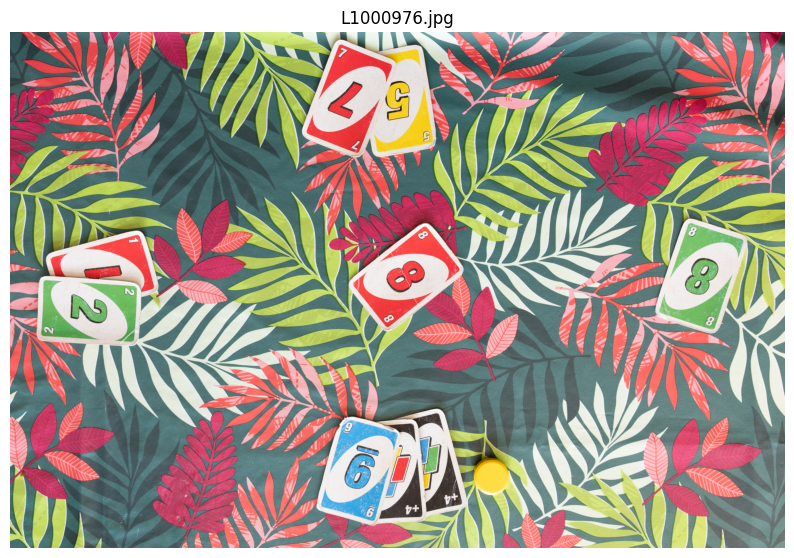

In [12]:
show_image(img_color, IMAGE_PATH.name)


## Image Type And Center Token

The pipeline first decides which center token is present from the image brightness, then locates the token with `get_token_center`.


Detected token type: yellow
Token center: (2486, 2299)


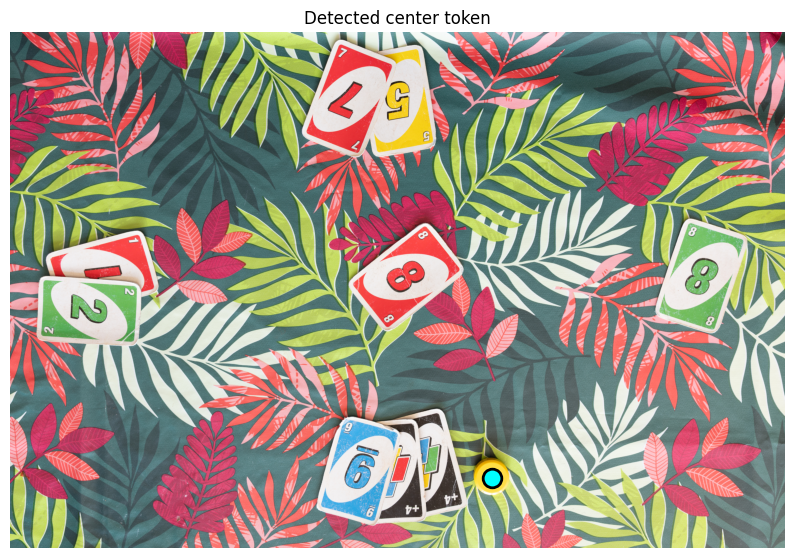

In [13]:
token = seg.image_token_type(img_color)
token_center = seg.get_token_center(img_color)
print(f"Detected token type: {token}")
print(f"Token center: {token_center}")

ax = show_image(img_color, "Detected center token")
if token_center is not None:
    ax.scatter(*token_center, s=180, c="cyan", edgecolors="black", linewidths=2)


## Color Masks

HSV thresholds are loaded from `hsv_thresholds/`, closed morphologically, and filtered by minimum component area through `get_color_masks`.


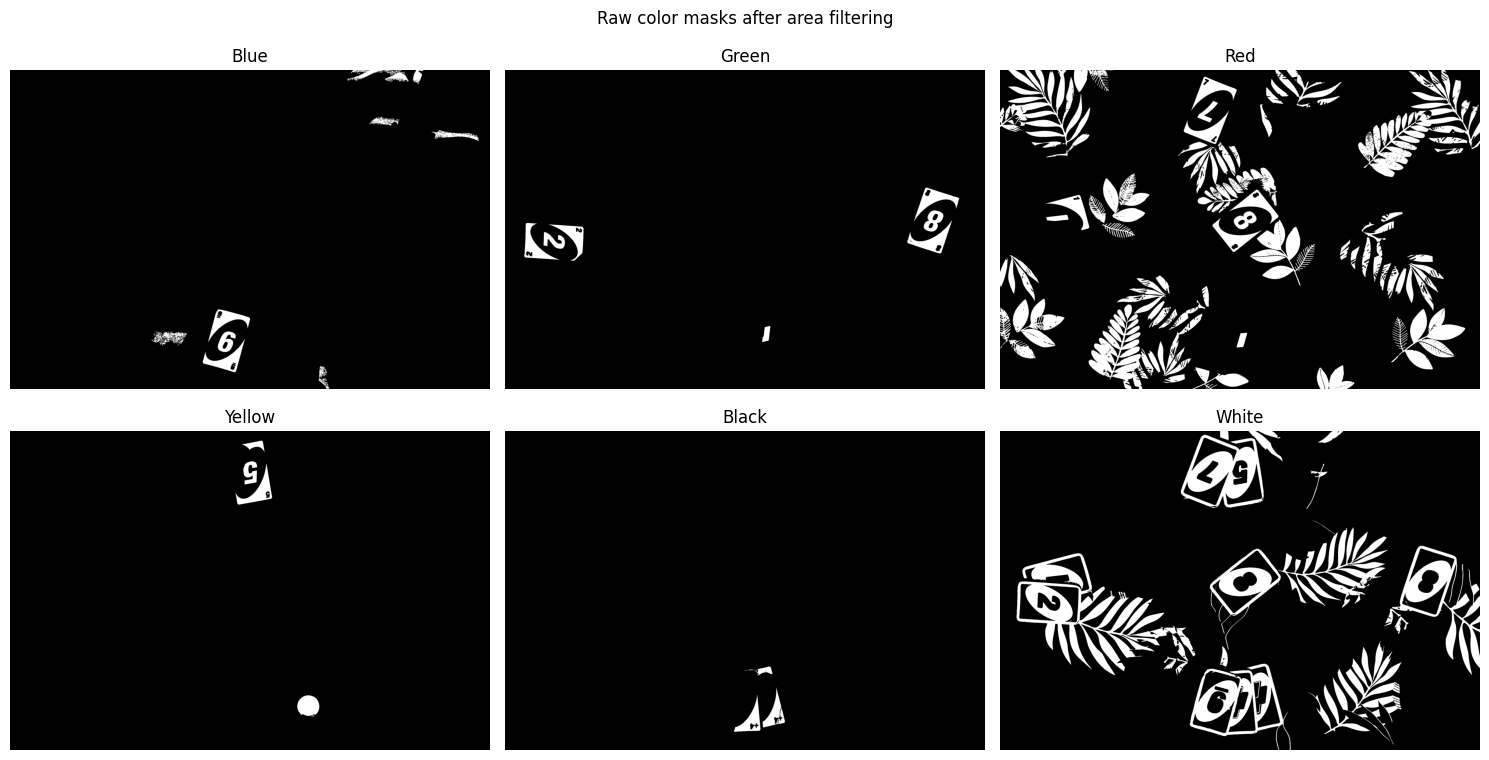

In [14]:
color_masks = seg.get_color_masks(img_color)
show_masks(color_masks, title="Raw color masks after area filtering")


## Token Removal

The token overlaps the same colors as cards, so it is removed before searching for card interiors.


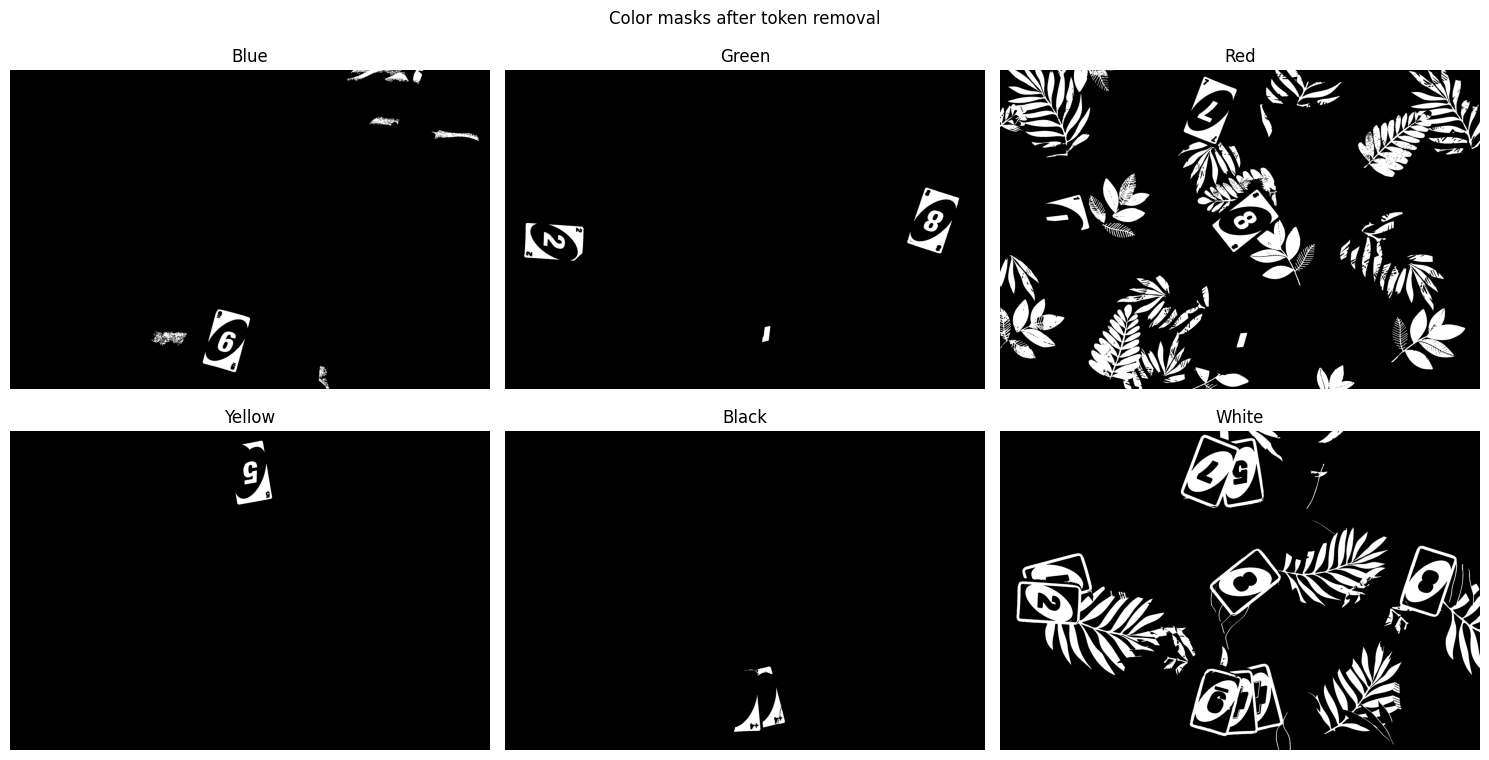

In [15]:
token_removed_masks = seg.remove_token_from_color_masks(
    img_color,
    {color: mask.copy() for color, mask in color_masks.items()},
)
show_masks(token_removed_masks, title="Color masks after token removal")


## Keep Card-Like Objects

Card objects are expected to be surrounded by white. `keep_white_surrounded_objects` removes colored regions that do not satisfy that constraint.


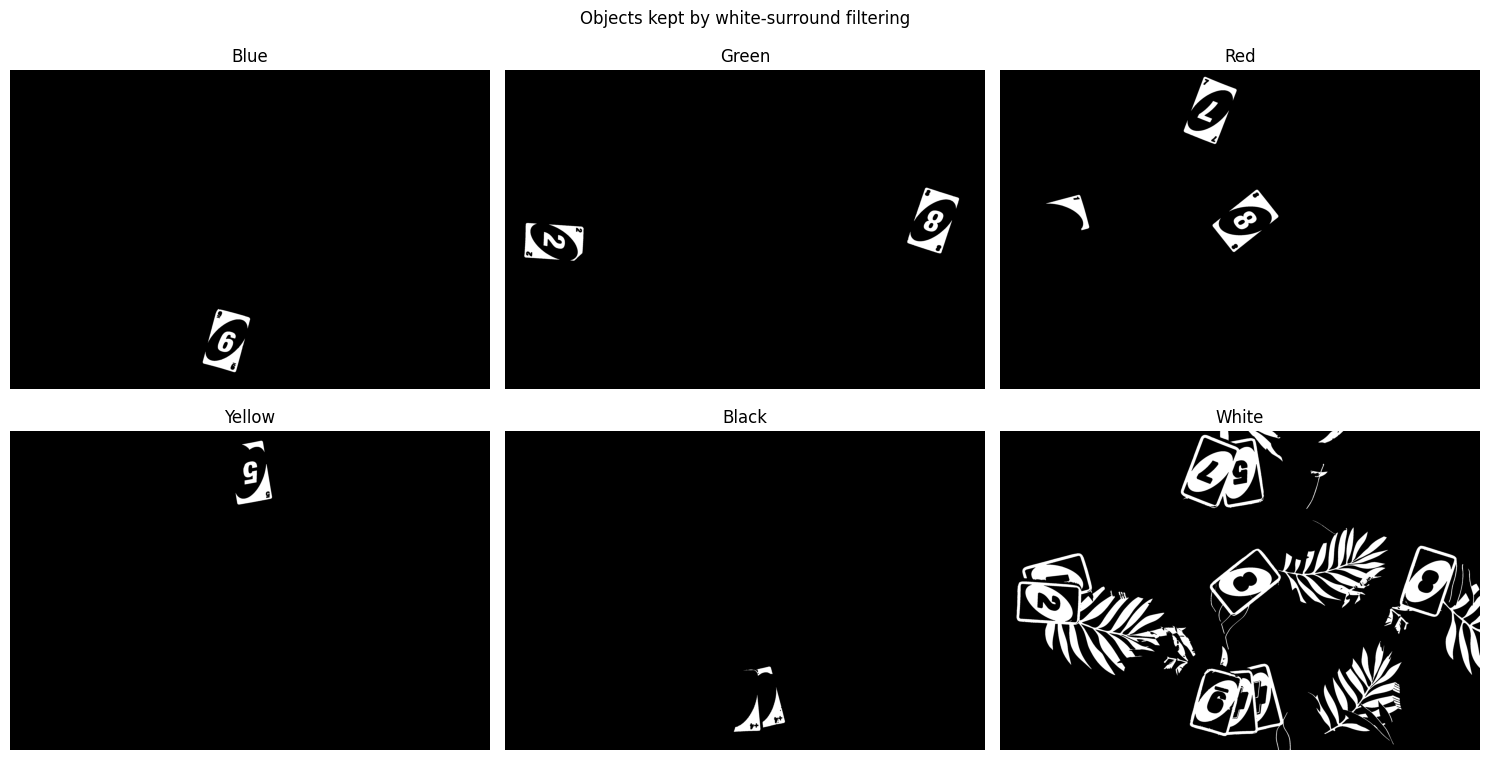

In [16]:
card_masks = seg.keep_white_surrounded_objects(
    {color: mask.copy() for color, mask in token_removed_masks.items()}
)
show_masks(card_masks, title="Objects kept by white-surround filtering")


## Holes Inside Card Shapes

UNO symbols appear as holes inside the colored card regions. The helper functions below are only used for visualization of that intermediate idea.


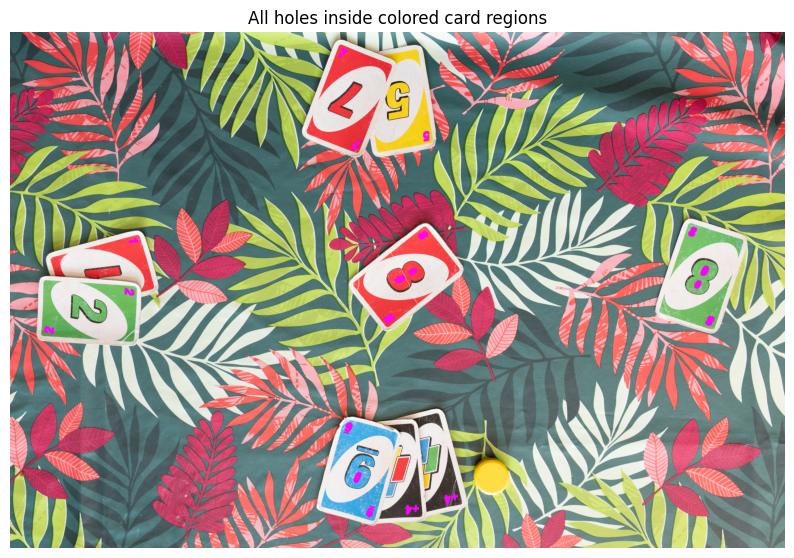

In [17]:
hole_masks = {
    color: seg.get_holes(mask, min_hole_area=100)
    for color, mask in card_masks.items()
    if color != "white"
}
all_holes = np.bitwise_or.reduce(list(hole_masks.values()))
overlay_mask(img_color, all_holes, title="All holes inside colored card regions")


## Filtered Symbol Masks

`extract_symbols_mask_per_color` keeps only holes that overlap the white symbol pixels in the original image, producing the final symbol mask for each card color. We also remove additional candidates that don't satisfy a certain condition (white dilation).


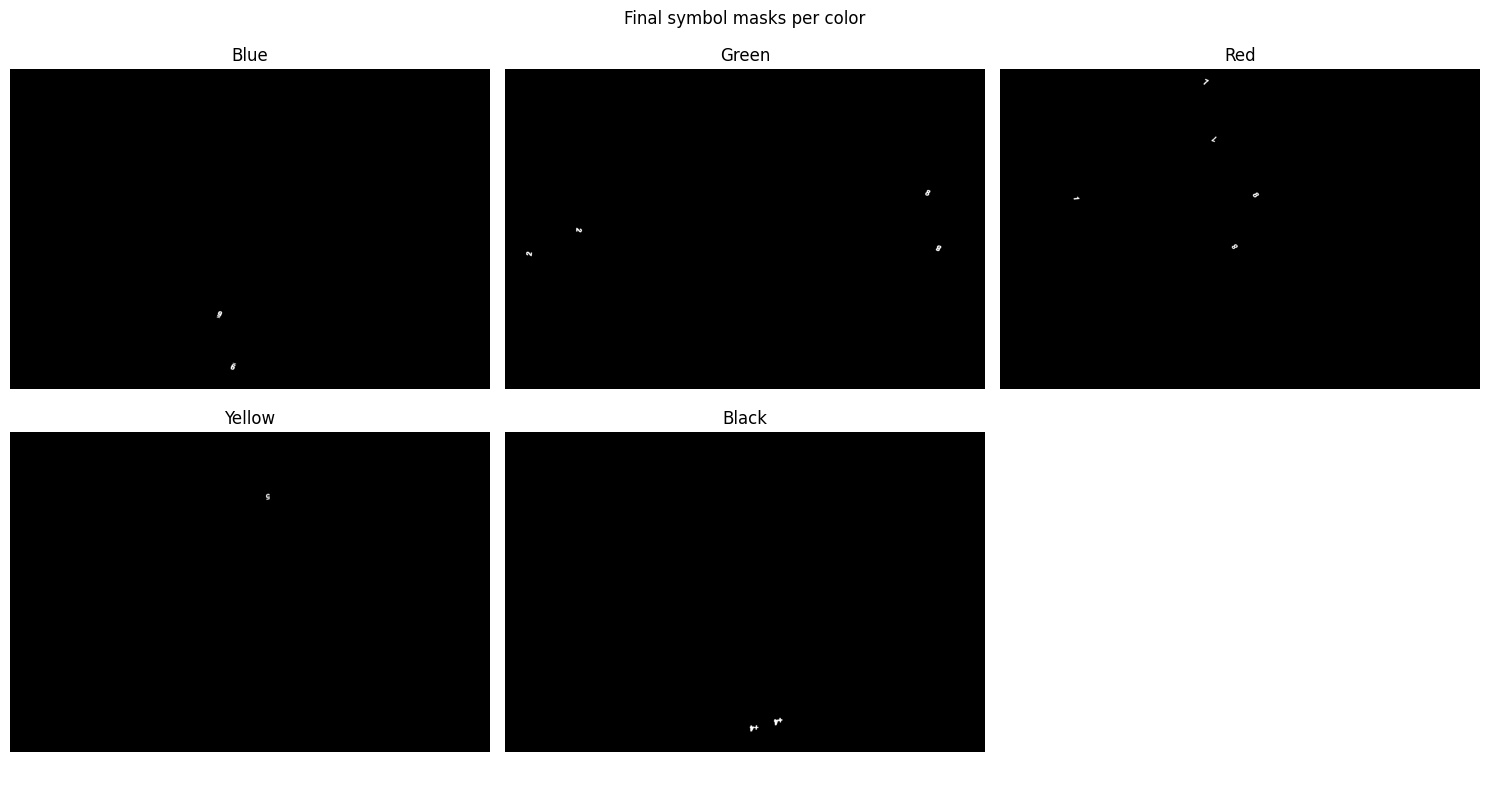

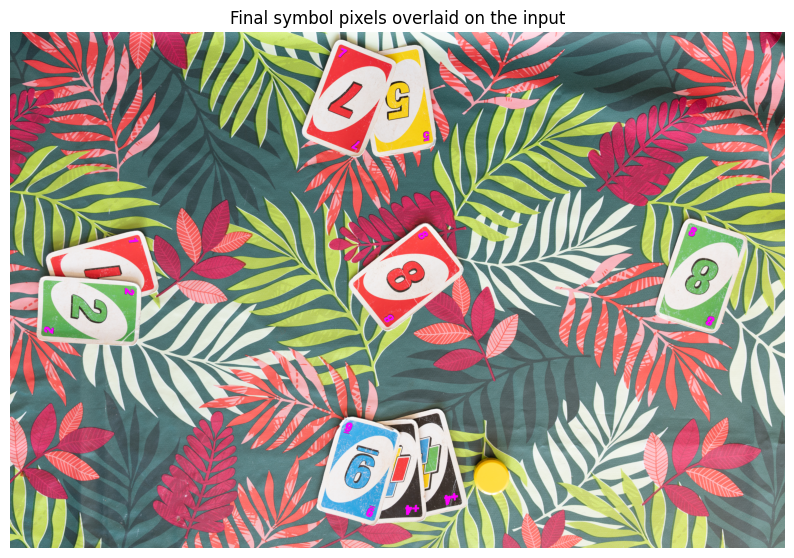

In [18]:
symbols_mask_per_color = seg.extract_symbols_mask_per_color(img_color, card_masks)
total_symbol_mask = np.bitwise_or.reduce(list(symbols_mask_per_color.values()))

show_masks(symbols_mask_per_color, columns=3, title="Final symbol masks per color")
overlay_mask(img_color, total_symbol_mask, title="Final symbol pixels overlaid on the input")


## Extracted Symbol Patches

`detect_symbols` merges nearby symbol pixels and returns classifier-ready binary patches with their card color and image center.


Detected symbols: 14


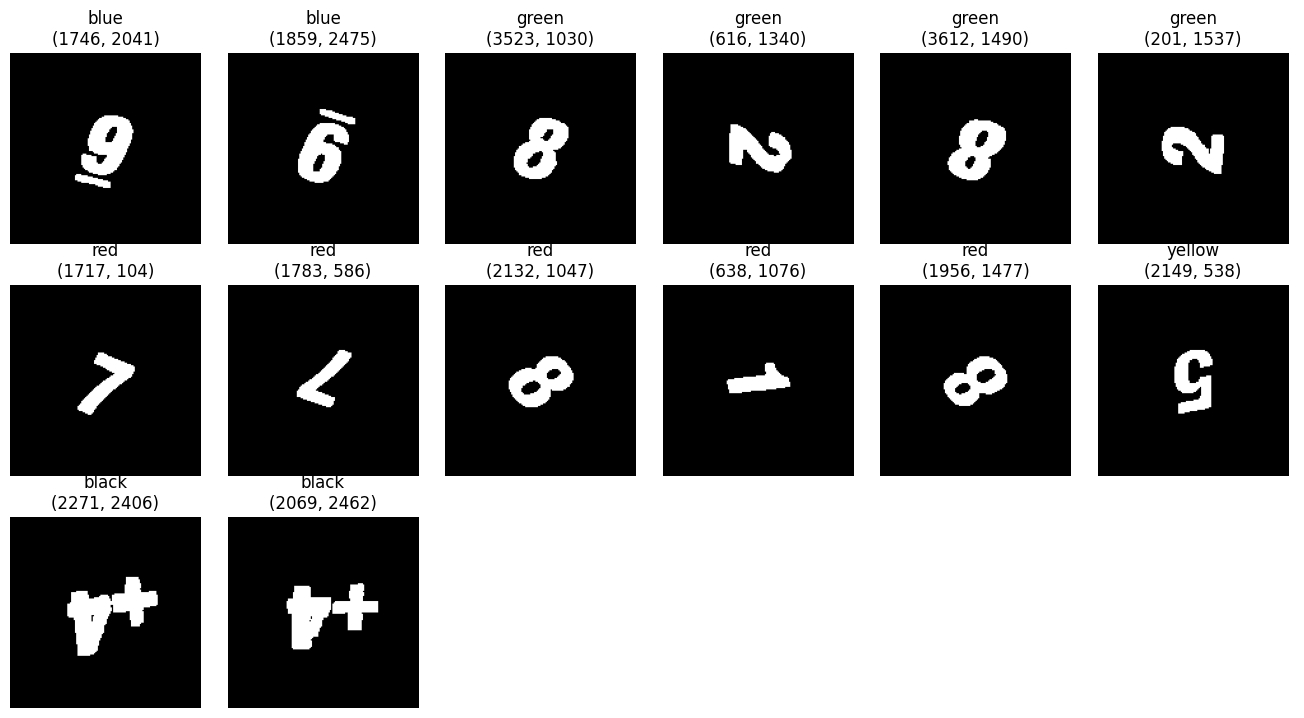

In [19]:
detected_symbols = seg.detect_symbols(img_color)
print(f"Detected symbols: {len(detected_symbols)}")

columns = min(6, max(1, len(detected_symbols)))
rows = int(np.ceil(len(detected_symbols) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(2.2 * columns, 2.4 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, (patch, color, center_xy) in zip(axes, detected_symbols):
    ax.imshow(patch, cmap="gray")
    ax.set_title(f"{color}\n({center_xy[0]:.0f}, {center_xy[1]:.0f})")
    ax.axis("off")

for ax in axes[len(detected_symbols):]:
    ax.axis("off")

plt.tight_layout()
